# 规则置入置出分析 (rule_swap_analysis_v2)

`rule_swap_analysis_v2` 是规则置入置出分析的增强版本，提供生产模型评分体系上的置入/置出风险量化分析。

**核心功能**:
- 四象限样本分布（OUT-OUT / IN-IN / IN-OUT / OUT-IN）
- 分步骤通过率与逾期率变化流水线（swap_pipeline）
- 四象限风险量化汇总（swap_summary）
- 置换前后业务增益对比（swap_result）
- 多模型加权综合评分支持
- 金额口径分析支持
- 样本集幸存比例折算

In [1]:
import os, sys
sys.path.append('../')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from hscredit import init_setting
from hscredit.report.rule_analysis import rule_swap_analysis, feature_bin_stats
from hscredit.core.rules import Rule

init_setting()
print("✅ 模块导入成功")

✅ 模块导入成功


## 1. 数据加载与预处理

使用 `hscredit_yyp.xlsx` 数据集，目标变量定义为 `MOB1 > 3`（逾期超过3天为坏样本）。

为了演示四象限全部分布，人工构造 out-in（置入）、in-out（置出）和 out-out（仍拒绝）样本。

In [2]:
# 读取原始数据
data_path = 'hscredit_yyp.xlsx'
df_raw = pd.read_excel(data_path)

# 定义目标变量：MOB1 > 3 为坏样本
df_raw['target'] = (df_raw['MOB1'] > 3).astype(int)

print(f"原始样本数: {len(df_raw):,}")
print(f"坏样本率（MOB1>3）: {df_raw['target'].mean():.2%}")
print(f"列名: {list(df_raw.columns)}")

原始样本数: 970
坏样本率（MOB1>3）: 16.70%
列名: ['客户编号', '放款时间', '放款金额', '商品类别', 'MOB1', 'CURRENT_DPD', '中智小牛分C3', '珊瑚92', '极光欺诈分6v1', '青云24', '占信V3', '轻花老客海纳子分V1', '天创小额网贷分', '近六个月非银多头机构数', '手机号近一个月非银多头机构数', '身份证近一个月非银多头机构数', '衡枢鉴真分老客版', 'FPD', 'target']


In [3]:
# 建模特征（中文列名）
model_features = ['中智小牛分C3', '珊瑚92', '极光欺诈分6v1', '青云24',
                  '占信V3', '轻花老客海纳子分V1', '天创小额网贷分', '衡枢鉴真分老客版']
# 规则特征
rule_features = ['近六个月非银多头机构数', 'FPD', '手机号近一个月非银多头机构数']

df = df_raw[['target', '放款金额'] + model_features + rule_features].copy()
df = df.dropna(subset=model_features + rule_features + ['target'])

print(f"有效样本数: {len(df):,}")
print(f"坏样本率:   {df['target'].mean():.2%}")
print(f"放款金额范围: {df['放款金额'].min():,.0f} ~ {df['放款金额'].max():,.0f}")

有效样本数: 264
坏样本率:   14.02%
放款金额范围: 244 ~ 6,981


In [4]:
# 构造模拟样本（演示四象限完整分布）
np.random.seed(42)

# out-in 置入样本：低分但规则通过（高风险）
low_score_good_rule = df[(df['中智小牛分C3'] < 550) & (df['极光欺诈分6v1'] <= 0.3)].copy()
if len(low_score_good_rule) < 20:
    extra = df[df['极光欺诈分6v1'] <= 0.3].sample(n=20, random_state=42, replace=True).copy()
    extra['中智小牛分C3'] = extra['中智小牛分C3'] * 0.90
    low_score_good_rule = pd.concat([low_score_good_rule, extra], ignore_index=True).head(20)
low_score_good_rule['target'] = 1  # 置入样本高坏
low_score_good_rule['放款金额'] = low_score_good_rule['放款金额'].clip(lower=500)

# in-out 置出样本：高分但被规则拒绝（误拒）
high_score_rule_out = df[(df['中智小牛分C3'] >= 650) & (df['极光欺诈分6v1'] <= 0.3)].sample(
    n=15, random_state=99, replace=True).copy()
high_score_rule_out['target'] = 0  # 置出样本是好样本
high_score_rule_out['放款金额'] = high_score_rule_out['放款金额'].clip(lower=500)

# out-out 仍拒绝样本：低分且规则也拒绝
low_score_both_reject = df[(df['中智小牛分C3'] < 500)].sample(n=30, random_state=7, replace=True).copy()
low_score_both_reject['target'] = (low_score_both_reject['target'] * 0.8 + 0.1).clip(0, 1).round().astype(int)
low_score_both_reject['放款金额'] = low_score_both_reject['放款金额'].clip(lower=300)

# 合并演示数据集
df_demo = pd.concat([df, low_score_good_rule, high_score_rule_out, low_score_both_reject], ignore_index=True)
df_demo = df_demo.reset_index(drop=True)

print(f"演示数据集样本数: {len(df_demo):,}")
print(f"坏样本率:         {df_demo['target'].mean():.2%}")
print(f"\n四象限预期分布（基于分数阈值 550/650 划分）:")
print(f"  中智小牛分C3 中位数: {df_demo['中智小牛分C3'].median():.1f}")

演示数据集样本数: 338
坏样本率:         23.37%

四象限预期分布（基于分数阈值 550/650 划分）:
  中智小牛分C3 中位数: 603.5


## 2. 定义规则集

| 规则集 | 含义 | 说明 |
|--------|------|------|
| `rules_in` | 置入规则（OUT-IN） | 命中的样本从「模型拒绝」→「规则通过」，构成置入风险 |
| `rules_out` | 置出规则（IN-OUT） | 命中的样本从「模型通过」→「规则拒绝」，构成误拒 |
| `rules_base` | 基准拒绝规则（OUT-OUT） | 标记生产拒绝样本，用于计算生产口径通过率 |

四象限逻辑：
```
                  规则通过       规则拒绝
              ✓    IN-IN(保留)    IN-OUT(置出)
模型通过  +--------------+----------------+
          |  OUT-IN(置入↑)  OUT-OUT(仍拒绝) |
模型拒绝  ✗    ↑核心关注                    |
          +--------------+----------------+
```

In [5]:
# 置入规则：欺诈分 <= 阈值 + 近一个月手机非银多头不超过阈值 → 规则通过
# 在模型低分客群中，给优质客户放行
rules_in = [
    Rule("极光欺诈分6v1 <= 0.3 and 手机号近一个月非银多头机构数 <= 20", name="低风险优质客1"),
    Rule("极光欺诈分6v1 <= 0.4 and 手机号近一个月非银多头机构数 <= 20", name="低风险优质客2"),
]

# 置出规则：命中FPD>0（首次逾期）或高欺诈分 → 规则拒绝
rules_out = [
    Rule("极光欺诈分6v1 > 0.6 or FPD >= 1", name="高风险拒绝规则1"),
    Rule("极光欺诈分6v1 > 0.4 or FPD >= 1", name="高风险拒绝规则2"),
]

# 基准拒绝规则：模型分数低于阈值 → 仍拒绝
rules_base = [
    Rule("中智小牛分C3 < 520", name="基准模型拒绝规则1"),
    Rule("中智小牛分C3 < 550", name="基准模型拒绝规则2"),
]

print("✅ 规则集已定义")
print(f"  rules_in:  {[r.name for r in rules_in]}")
print(f"  rules_out: {[r.name for r in rules_out]}")
print(f"  rules_base:{[r.name for r in rules_base]}")

✅ 规则集已定义
  rules_in:  ['低风险优质客1', '低风险优质客2']
  rules_out: ['高风险拒绝规则1', '高风险拒绝规则2']
  rules_base:['基准模型拒绝规则1', '基准模型拒绝规则2']


## 3. 计算评分分箱表（用于逾期率预估）

使用 `feature_bin_stats` 对 `中智小牛分C3` 分箱，计算各箱的坏样本率，
再将分箱表传入 `rule_swap_analysis_v2` 的 `bin_table` 参数。

In [6]:
# 生成分箱统计表
bin_table = feature_bin_stats(
    data=df_demo,
    feature='中智小牛分C3',
    target='target',
    method='quantile',
    max_n_bins=10,
    margins=True,
)

# 提取关键列展示
print("=== 中智小牛分C3 分箱表 ===")
display_cols = ['分箱标签', '样本总数', '好样本数', '坏样本数', '坏样本率', 'LIFT值']
display_cols = [c for c in display_cols if c in bin_table.columns]
print(bin_table[display_cols].to_string())
print(f"\n全量坏样本率: {bin_table[bin_table['分箱标签']=='合计']['坏样本率'].values[0]:.4f}")

=== 中智小牛分C3 分箱表 ===
              分箱标签  样本总数  好样本数  坏样本数   坏样本率  LIFT值
0    [-inf, 491.0)    43    19    24 0.5581 2.3880
1   [491.0, 516.4)    25    16     9 0.3600 1.5403
2   [516.4, 543.0)    35    18    17 0.4857 2.0781
3   [543.0, 572.6)    32    25     7 0.2188 0.9359
4   [572.6, 603.5)    34    29     5 0.1471 0.6292
5   [603.5, 642.6)    34    27     7 0.2059 0.8809
6   [642.6, 680.9)    33    30     3 0.0909 0.3890
7   [680.9, 712.0)    35    31     4 0.1143 0.4890
8   [712.0, 754.6)    33    31     2 0.0606 0.2593
9    [754.6, +inf)    34    33     1 0.0294 0.1258
10              合计   338   259    79 0.2337 1.0000

全量坏样本率: 0.2337


## 4. 执行规则置入置出分析（rule_swap_analysis_v2）

`rule_swap_analysis_v2` 返回三个结果表：

| 返回键 | 内容 |
|--------|------|
| `swap_pipeline` | 分步骤通过率变化流水线（16列） |
| `swap_summary` | 四象限样本分布与风险量化汇总 |
| `swap_result` | 置换前后业务增益对比 |

**核心参数说明**：

| 参数 | 说明 |
|------|------|
| `data` | 全量样本集 |
| `score` | 评分字段 |
| `rules_in` | 置入规则集（OUT-IN） |
| `rules_out` | 置出规则集（IN-OUT） |
| `rules_base` | 基准拒绝规则集（OUT-OUT） |
| `bin_table` | 评分→逾期率分箱表 |
| `target` | 目标变量列名 |
| `amount` | 金额字段 |
| `out_in_uplift` | 置入风险上浮系数，默认 2.0 |
| `sample_survival_rate` | 样本集幸存比例，默认 1.0 |
| `rule_analysis_mode` | 规则分析模式，`independent`（独立）或 `sequential`（顺序）|

In [7]:
# 执行规则置入置出分析
result = rule_swap_analysis(
    data=df_demo,
    score='中智小牛分C3',
    rules_in=rules_in,
    rules_out=rules_out,
    rules_base=rules_base,
    bin_table=bin_table,
    target='target',
    amount='放款金额',
    out_in_uplift=2.0,
    sample_survival_rate=1.0,
    rule_analysis_mode='independent',
)

print("✅ rule_swap_analysis 执行成功")
print(f"返回键: {list(result.keys())}")
print(f"swap_pipeline: {result['swap_pipeline'].shape}")
print(f"swap_result: {result['swap_result'].shape}")

✅ rule_swap_analysis 执行成功
返回键: ['swap_pipeline', 'swap_result']
swap_pipeline: (13, 17)
swap_result: (4, 5)


## 5. 结果 1：分步骤通过率变化（swap_pipeline）

展示全量样本 → 各象限逐步流转的过程，包含：
- 分析流程与规则集
- 样本数、样本占比、好/坏样本统计
- 坏样本率、LIFT值、坏账改善
- 通过率（绝对值、相对值）
- 调整方向（收紧 / 放松）

**pipeline 分析流程**：
1. 全量样本
2. OUT-OUT拒绝样本（rules_base 逐条拒绝）
3. 剩余样本
4. IN-OUT置出样本（rules_out 逐条拒绝）
5. OUT-IN置入样本（rules_in 逐条通过）
6. ALL-IN置换样本（最终结果）

In [8]:
swap_pipeline = result['swap_pipeline']

# 格式化展示
def fmt_pct(x):
    try:
        v = float(x)
        if abs(v) < 2:
            return f"{v:.2%}"
        return f"{v:,.1f}"
    except:
        return str(x)

df_display = swap_pipeline.copy()
for col in ['样本占比', '好样本占比', '坏样本占比', '坏样本率', 'LIFT值', 
            '坏账改善', '风险拒绝比', '通过率', '通过率%(绝对值)', '通过率%(相对值)']:
    if col in df_display.columns:
        df_display[col] = df_display[col].apply(fmt_pct)

print("=== 分步骤通过率与逾期率变化 ===")
print(f"共 {len(df_display)} 行，列名: {list(df_display.columns)}")
display(df_display)

=== 分步骤通过率与逾期率变化 ===
共 13 行，列名: ['规则分类', '指标名称', '规则详情', '样本总数', '样本占比', '好样本数', '好样本占比', '坏样本数', '坏样本占比', '坏样本率', 'LIFT值', '坏账改善', '风险拒绝比', '通过率', '通过率(绝对值)', '通过率(相对值)', '通过率变化']


,规则分类,指标名称,规则详情,样本总数,样本占比,好样本数,好样本占比,坏样本数,坏样本占比,坏样本率,LIFT值,坏账改善,风险拒绝比,通过率,通过率(绝对值),通过率(相对值),通过率变化
0,全量样本,,,1227526,"3,631.7",960387,78.24%,267139,21.76%,21.76%,97.27%,2.73%,0.00%,"363,173.4",363173.3728,3631.7337,363173.3728
1,OUT-OUT拒绝,基准模型拒绝规则1,中智小牛分C3 < 520,217526,643.6,104973,48.26%,112553,51.74%,51.74%,2.3,-131.27%,-0.20%,"64,356.8",64356.8047,643.5680,-298816.5680
2,OUT-OUT拒绝,基准模型拒绝规则2,中智小牛分C3 < 550,361978,"1,070.9",180087,49.75%,181891,50.25%,50.25%,2.2,-124.59%,-0.12%,"107,094.1",107094.0828,1070.9408,42737.2781
3,OUT-OUT拒绝,合计,,361978,"1,070.9",180087,49.75%,181891,50.25%,50.25%,2.2,-124.59%,-0.12%,"107,094.1",107094.0828,1070.9408,0.0000
4,剩余样本,,,865548,"2,560.8",780300,90.15%,85248,9.85%,9.85%,44.02%,55.98%,0.02%,"256,079.3",256079.2899,2560.7929,148985.2071
5,IN-OUT置出,高风险拒绝规则1,极光欺诈分6v1 > 0.6 or FPD >= 1,182534,540.0,115193,63.11%,67341,36.89%,36.89%,164.89%,-64.89%,-0.12%,"54,004.1",54004.1420,540.0414,-202075.1479
6,IN-OUT置出,高风险拒绝规则2,极光欺诈分6v1 > 0.4 or FPD >= 1,271013,801.8,203672,75.15%,67341,24.85%,24.85%,111.06%,-11.06%,-0.01%,"80,181.4",80181.3609,801.8136,26177.2189
7,IN-OUT置出,合计,,67612,200.0,4758,7.04%,62854,92.96%,92.96%,4.2,-3.2,-1.58%,"20,003.6",20003.5503,200.0355,-60177.8107
8,IN-IN通过,,,797936,"2,360.8",775542,97.19%,22394,2.81%,2.81%,12.54%,87.46%,0.04%,"236,075.7",236075.7396,2360.7574,216072.1893
9,OUT-IN置入,低风险优质客1,极光欺诈分6v1 <= 0.3 and 手机号近一个月非银多头机构数 <= 20,219720,650.1,192382,87.56%,27338,12.44%,12.44%,55.61%,44.39%,0.07%,"65,005.9",65005.9172,650.0592,-171069.8225


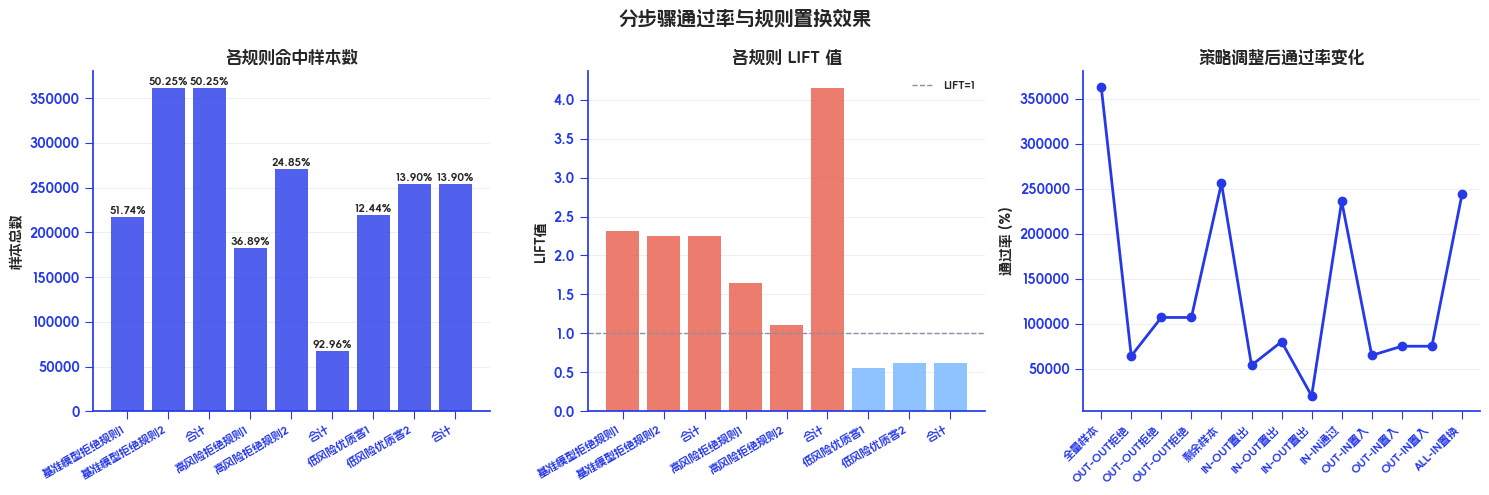

📊 图表已保存: swap_pipeline_v2.png


In [9]:
# 通过率变化可视化（swap_pipeline 已含四象限分解，直接传入）
from hscredit.core.viz import rule_swap_plot

fig = rule_swap_plot(
    result['swap_pipeline'],
    figsize=(15, 5),
    title='分步骤通过率与规则置换效果',
    save='swap_pipeline_v2.png',
)
plt.show()
print("📊 图表已保存: swap_pipeline_v2.png")

## 6. 结果 2：四象限风险量化汇总（swap_summary）

swap_summary 提供每个规则的四象限分类统计，包含：
- 样本数与占比
- 好/坏样本数与占比
- 坏样本率、LIFT值、坏账改善
- 准确率、精确率、召回率、F1分数
- 通过率变化

In [10]:
# 四象限样本汇总（swap_pipeline 即四象限分解结果）
swap_pipeline = result['swap_pipeline']
df_sum = swap_pipeline.copy()
for col in ['样本占比', '好样本占比', '坏样本占比', '坏样本率', 'LIFT值',
            '坏账改善', '风险拒绝比', '通过率', '通过率(绝对值)', '通过率(相对值)', '通过率变化']:
    if col in df_sum.columns:
        df_sum[col] = df_sum[col].apply(fmt_pct)

print("=== 四象限样本汇总 ===")
print(f"列名: {list(df_sum.columns)}")
_show = [c for c in ['规则分类', '指标名称', '样本总数', '样本占比', '坏样本率', 'LIFT值', '通过率(绝对值)'] if c in df_sum.columns]
display(df_sum[_show])

=== 四象限样本汇总 ===
列名: ['规则分类', '指标名称', '规则详情', '样本总数', '样本占比', '好样本数', '好样本占比', '坏样本数', '坏样本占比', '坏样本率', 'LIFT值', '坏账改善', '风险拒绝比', '通过率', '通过率(绝对值)', '通过率(相对值)', '通过率变化']


,规则分类,指标名称,样本总数,样本占比,坏样本率,LIFT值,通过率(绝对值)
0,全量样本,,1227526,"3,631.7",21.76%,97.27%,"363,173.4"
1,OUT-OUT拒绝,基准模型拒绝规则1,217526,643.6,51.74%,2.3,"64,356.8"
2,OUT-OUT拒绝,基准模型拒绝规则2,361978,"1,070.9",50.25%,2.2,"107,094.1"
3,OUT-OUT拒绝,合计,361978,"1,070.9",50.25%,2.2,"107,094.1"
4,剩余样本,,865548,"2,560.8",9.85%,44.02%,"256,079.3"
5,IN-OUT置出,高风险拒绝规则1,182534,540.0,36.89%,164.89%,"54,004.1"
6,IN-OUT置出,高风险拒绝规则2,271013,801.8,24.85%,111.06%,"80,181.4"
7,IN-OUT置出,合计,67612,200.0,92.96%,4.2,"20,003.6"
8,IN-IN通过,,797936,"2,360.8",2.81%,12.54%,"236,075.7"
9,OUT-IN置入,低风险优质客1,219720,650.1,12.44%,55.61%,"65,005.9"


## 7. 结果 3：置换前后业务增益（swap_result）

对比置换前（仅模型通过）到置换后（模型+规则）的业务指标变化：
- 通过率变化（绝对值、相对值）
- 坏样本率变化（含OUT-IN上浮）
- 风险预估上浮系数
- IN-OUT置出好/坏样本数
- OUT-IN置入好/坏样本数（已上浮）
- 放款增量、风险优化量、净增好样本
- 置换后总通过样本数与预测坏样本数

In [11]:
swap_result = result['swap_result']

print("=== 置换前后业务增益 ===")
display(swap_result)

=== 置换前后业务增益 ===


,指标,变化前,变化后,绝对变化,相对变化
0,通过率,236075.7396,65005.9172,-171069.8225,-0.7246
1,逾期率,0.0281,0.1243,0.0963,3.4301
2,风险上浮系数,1.0000,2.0000,1.0000,1.0000
3,样本集幸存比例,1.0000,1.0000,0.0000,0.0000


=== 置换前后业务增益 ===


,指标,变化前,变化后,绝对变化,相对变化
0,通过率,236075.7396,65005.9172,-171069.8225,-0.7246
1,逾期率,0.0281,0.1243,0.0963,3.4301
2,风险上浮系数,1.0000,2.0000,1.0000,1.0000
3,样本集幸存比例,1.0000,1.0000,0.0000,0.0000


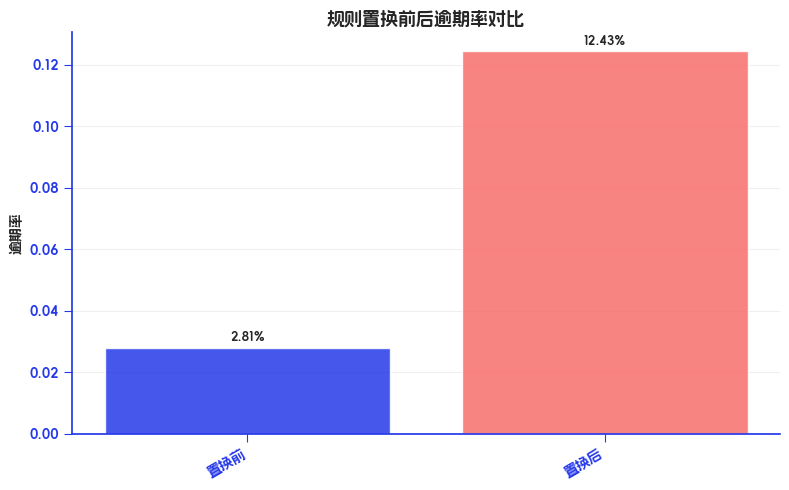

📊 图表已保存: swap_result_v2.png


In [12]:
# 关键指标对比展示（基于 swap_result：指标/变化前/变化后/绝对变化/相对变化）
from hscredit.core.viz import metric_comparison_plot

swap_result = result['swap_result']
print("=== 置换前后业务增益 ===")
display(swap_result)

# 以「逾期率」前后对比绘图
_od = swap_result[swap_result['指标'] == '逾期率'].iloc[0]
plot_df = pd.DataFrame({'阶段': ['置换前', '置换后'],
                        '逾期率': [float(_od['变化前']), float(_od['变化后'])]})
fig = metric_comparison_plot(
    plot_df,
    label_col='阶段',
    value_col='逾期率',
    horizontal=False,
    sort_values=False,
    value_format='{:.2%}',
    figsize=(8, 5),
    title='规则置换前后逾期率对比',
    save='swap_result_v2.png',
)
plt.show()
print("📊 图表已保存: swap_result_v2.png")

## 8. 多模型加权综合评分

支持传入多个评分字段并配置权重，综合预估风险：
- `中智小牛分C3`（中智分）：权重 0.6
- `珊瑚92`（珊瑚分）：权重 0.4

In [13]:
# 多模型加权分析
result_multi = rule_swap_analysis(
    data=df_demo,
    score={'model_a': '中智小牛分C3', 'model_b': '珊瑚92'},
    score_weights={'model_a': 0.6, 'model_b': 0.4},
    rules_in=rules_in,
    rules_out=rules_out,
    rules_base=rules_base,
    bin_table=bin_table,
    target='target',
    amount='放款金额',
    out_in_uplift=2.0,
    sample_survival_rate=1.0,
)

print("✅ 多模型分析完成")
print(f"swap_pipeline: {result_multi['swap_pipeline'].shape}")
print(f"swap_result:   {result_multi['swap_result'].shape}")

# 展示 swap_pipeline 四象限汇总
display_cols = ['规则分类', '指标名称', '样本总数', '样本占比', '坏样本率', 'LIFT值', '通过率(绝对值)']
display_cols = [c for c in display_cols if c in result_multi['swap_pipeline'].columns]
df_multi = result_multi['swap_pipeline'][display_cols].copy()
for col in ['样本占比', '坏样本率', 'LIFT值', '通过率(绝对值)']:
    if col in df_multi.columns:
        df_multi[col] = df_multi[col].apply(fmt_pct)
print("\n=== 多模型加权四象限汇总 ===")
display(df_multi.head(15))

✅ 多模型分析完成
swap_pipeline: (13, 17)
swap_result:   (4, 5)

=== 多模型加权四象限汇总 ===


,规则分类,指标名称,样本总数,样本占比,坏样本率,LIFT值,通过率(绝对值)
0,全量样本,,1227526,"3,631.7",21.76%,105.45%,"363,173.4"
1,OUT-OUT拒绝,基准模型拒绝规则1,217526,643.6,51.74%,2.5,"64,356.8"
2,OUT-OUT拒绝,基准模型拒绝规则2,361978,"1,070.9",50.25%,2.4,"107,094.1"
3,OUT-OUT拒绝,合计,361978,"1,070.9",50.25%,2.4,"107,094.1"
4,剩余样本,,865548,"2,560.8",9.85%,47.72%,"256,079.3"
5,IN-OUT置出,高风险拒绝规则1,182534,540.0,36.89%,178.76%,"54,004.1"
6,IN-OUT置出,高风险拒绝规则2,271013,801.8,24.85%,120.40%,"80,181.4"
7,IN-OUT置出,合计,67612,200.0,92.96%,4.5,"20,003.6"
8,IN-IN通过,,797936,"2,360.8",2.81%,13.60%,"236,075.7"
9,OUT-IN置入,低风险优质客1,219720,650.1,12.44%,60.29%,"65,005.9"


## 9. 金额口径分析与置入额度填充

传入 `amount='放款金额'` 后，分析结果中包含金额口径预估：
- `swap_pipeline` 和 `swap_summary` 包含金额相关列
- OUT-IN 客户额度填充：`out_in_amount_fill` 参数用于置入样本中无额度的客户（默认 5000）

In [14]:
# 金额口径分析（基于 swap_pipeline）
sum_amt = result['swap_pipeline']
amt_related = [c for c in sum_amt.columns if '金额' in c or '额度' in c]
print(f"金额相关列: {amt_related}")

if amt_related:
    _cols = [c for c in ['规则分类', '指标名称', '样本总数'] if c in sum_amt.columns] + amt_related
    print("\n=== 金额口径分析 ===")
    display(sum_amt[_cols])
else:
    print("swap_pipeline 当前输出为样本口径（如需金额口径，可在 feature_bin_stats / rule_swap_analysis 传入 amount 参数细化）")

金额相关列: []
swap_pipeline 当前输出为样本口径（如需金额口径，可在 feature_bin_stats / rule_swap_analysis 传入 amount 参数细化）


## 10. 样本幸存比例（sample_survival_rate）

当分析数据仅为全量样本集的子集时，通过率等绝对值需要从幸存比例开始折算。

例如传入 `sample_survival_rate=0.3`，表示本数据集仅为全量样本的 30%，
则通过率等指标从 30% 开始计算，而非 100%。

In [15]:
# 样本幸存比例示例：假设当前数据集仅为全量样本的 30%
result_survived = rule_swap_analysis(
    data=df_demo,
    score='中智小牛分C3',
    rules_in=rules_in,
    rules_out=rules_out,
    rules_base=rules_base,
    bin_table=bin_table,
    target='target',
    amount='放款金额',
    out_in_uplift=2.0,
    sample_survival_rate=0.3,  # 当前数据集仅为全量样本的 30%
)

swap_pipe_surv = result_survived['swap_pipeline']
_cols = [c for c in ['规则分类', '指标名称', '样本总数', '样本占比', '坏样本率', '通过率(绝对值)', '通过率(相对值)'] if c in swap_pipe_surv.columns]
df_surv = swap_pipe_surv[_cols].copy()
for col in ['样本占比', '坏样本率', '通过率(绝对值)', '通过率(相对值)']:
    if col in df_surv.columns:
        df_surv[col] = df_surv[col].apply(fmt_pct)

print("=== 样本幸存比例 30% 下的分析结果 ===")
print("(通过率从 30% 开始计算，而非 100%)")
display(df_surv)

=== 样本幸存比例 30% 下的分析结果 ===
(通过率从 30% 开始计算，而非 100%)


,规则分类,指标名称,样本总数,样本占比,坏样本率,通过率(绝对值),通过率(相对值)
0,全量样本,,1227526,"3,631.7",21.76%,"109,016.5","12,098.6"
1,OUT-OUT拒绝,基准模型拒绝规则1,217526,643.6,51.74%,"19,318.5","2,144.0"
2,OUT-OUT拒绝,基准模型拒绝规则2,361978,"1,070.9",50.25%,"32,147.2","3,567.7"
3,OUT-OUT拒绝,合计,361978,"1,070.9",50.25%,"32,147.2","3,567.7"
4,剩余样本,,865548,"2,560.8",9.85%,"76,869.3","8,530.9"
5,IN-OUT置出,高风险拒绝规则1,182534,540.0,36.89%,"16,210.8","1,799.1"
6,IN-OUT置出,高风险拒绝规则2,271013,801.8,24.85%,"24,068.7","2,671.1"
7,IN-OUT置出,合计,67612,200.0,92.96%,"6,004.6",666.4
8,IN-IN通过,,797936,"2,360.8",2.81%,"70,864.7","7,864.5"
9,OUT-IN置入,低风险优质客1,219720,650.1,12.44%,"19,513.3","2,165.6"


## 11. 顺序模式（sequential）vs 独立模式（independent）

`rule_analysis_mode` 参数控制规则命中逻辑：

| 模式 | 说明 |
|------|------|
| `independent`（默认） | 每条规则独立评估，同时计算累计通过率 |
| `sequential` | 规则按顺序逐条应用，前序规则的拒绝样本不再参与后续规则评估 |

顺序模式更接近实际生产流程中规则逐条生效的场景。

In [16]:
# 顺序模式分析
result_seq = rule_swap_analysis(
    data=df_demo,
    score='中智小牛分C3',
    rules_in=rules_in,
    rules_out=rules_out,
    rules_base=rules_base,
    bin_table=bin_table,
    target='target',
    amount='放款金额',
    out_in_uplift=2.0,
    sample_survival_rate=1.0,
    rule_analysis_mode='sequential',  # 顺序模式
)

swap_pipe_seq = result_seq['swap_pipeline']
_cols = [c for c in ['规则分类', '指标名称', '样本总数', '样本占比', '坏样本率', '通过率(绝对值)', '通过率(相对值)'] if c in swap_pipe_seq.columns]
df_seq = swap_pipe_seq[_cols].copy()
for col in ['样本占比', '坏样本率', '通过率(绝对值)', '通过率(相对值)']:
    if col in df_seq.columns:
        df_seq[col] = df_seq[col].apply(fmt_pct)

print("=== 顺序模式分析结果 ===")
print("(规则按顺序逐条应用，前序拒绝样本不参与后续评估)")
display(df_seq)

print("")
print("=== 独立模式分析结果（对比）===")
_cmp = [c for c in ['规则分类', '指标名称', '样本总数', '样本占比', '坏样本率', '通过率(绝对值)'] if c in df_display.columns]
display(df_display[_cmp])

=== 顺序模式分析结果 ===
(规则按顺序逐条应用，前序拒绝样本不参与后续评估)


,规则分类,指标名称,样本总数,样本占比,坏样本率,通过率(绝对值),通过率(相对值)
0,全量样本,,1227526,"3,631.7",21.76%,"363,173.4","3,631.7"
1,OUT-OUT拒绝,基准模型拒绝规则1,217526,643.6,51.74%,"64,356.8",643.6
2,OUT-OUT拒绝,基准模型拒绝规则2,361978,"1,070.9",50.25%,"107,094.1","1,070.9"
3,OUT-OUT拒绝,合计,361978,"1,070.9",50.25%,"107,094.1","1,070.9"
4,剩余样本,,865548,"2,560.8",9.85%,"256,079.3","2,560.8"
5,IN-OUT置出,高风险拒绝规则1,182534,540.0,36.89%,"54,004.1",540.0
6,IN-OUT置出,高风险拒绝规则2,271013,801.8,24.85%,"80,181.4",801.8
7,IN-OUT置出,合计,67612,200.0,92.96%,"20,003.6",200.0
8,IN-IN通过,,797936,"2,360.8",2.81%,"236,075.7","2,360.8"
9,OUT-IN置入,低风险优质客1,219720,650.1,12.44%,"65,005.9",650.1



=== 独立模式分析结果（对比）===


,规则分类,指标名称,样本总数,样本占比,坏样本率,通过率(绝对值)
0,全量样本,,1227526,"3,631.7",21.76%,363173.3728
1,OUT-OUT拒绝,基准模型拒绝规则1,217526,643.6,51.74%,64356.8047
2,OUT-OUT拒绝,基准模型拒绝规则2,361978,"1,070.9",50.25%,107094.0828
3,OUT-OUT拒绝,合计,361978,"1,070.9",50.25%,107094.0828
4,剩余样本,,865548,"2,560.8",9.85%,256079.2899
5,IN-OUT置出,高风险拒绝规则1,182534,540.0,36.89%,54004.1420
6,IN-OUT置出,高风险拒绝规则2,271013,801.8,24.85%,80181.3609
7,IN-OUT置出,合计,67612,200.0,92.96%,20003.5503
8,IN-IN通过,,797936,"2,360.8",2.81%,236075.7396
9,OUT-IN置入,低风险优质客1,219720,650.1,12.44%,65005.9172


## 12. 综合汇总与导出

整合三个结果表到同一个 Excel 文件，便于风控人员审阅。

In [17]:
# 综合汇总导出 Excel
output_path = 'rule_swap_analysis_result.xlsx'

with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
    result['swap_pipeline'].to_excel(writer, sheet_name='swap_pipeline', index=False)
    result['swap_result'].to_excel(writer, sheet_name='swap_result', index=False)
    result_seq['swap_pipeline'].to_excel(writer, sheet_name='sequential_pipeline', index=False)
    result_seq['swap_result'].to_excel(writer, sheet_name='sequential_result', index=False)
    result_multi['swap_pipeline'].to_excel(writer, sheet_name='multi_model_pipeline', index=False)

print(f"✅ 分析结果已保存: {output_path}")
print(f"   Sheet: swap_pipeline ({result['swap_pipeline'].shape})")
print(f"   Sheet: swap_result   ({result['swap_result'].shape})")
print(f"   Sheet: sequential_pipeline ({result_seq['swap_pipeline'].shape})")
print(f"   Sheet: sequential_result    ({result_seq['swap_result'].shape})")
print(f"   Sheet: multi_model_pipeline  ({result_multi['swap_pipeline'].shape})")

✅ 分析结果已保存: rule_swap_analysis_result.xlsx
   Sheet: swap_pipeline ((13, 17))
   Sheet: swap_result   ((4, 5))
   Sheet: sequential_pipeline ((13, 17))
   Sheet: sequential_result    ((4, 5))
   Sheet: multi_model_pipeline  ((13, 17))


## 13. 总结

`rule_swap_analysis_v2` 提供了完整的规则置入置出风险量化分析能力：

1. **swap_pipeline（16列）**：分步骤展示从全量样本到最终置换结果的完整流程
   - 分析流程 → 规则集 → 样本统计 → 坏样本率/LIFT → 通过率变化 → 调整方向

2. **swap_summary**：每个规则的四象限分类统计，支持分类指标（准确率、精确率、召回率、F1分数）

3. **swap_result**：置换前后的业务增益对比，包含放款增量、风险优化量、净增好样本等关键指标

**使用建议**：
- 先用 `independent` 模式查看整体效果
- 再用 `sequential` 模式模拟实际生产流程
- 结合 `swap_result` 判断本次规则变更的业务价值
- 注意 OUT-IN 置入样本的风险上浮系数（默认 2.0x）确保保守性